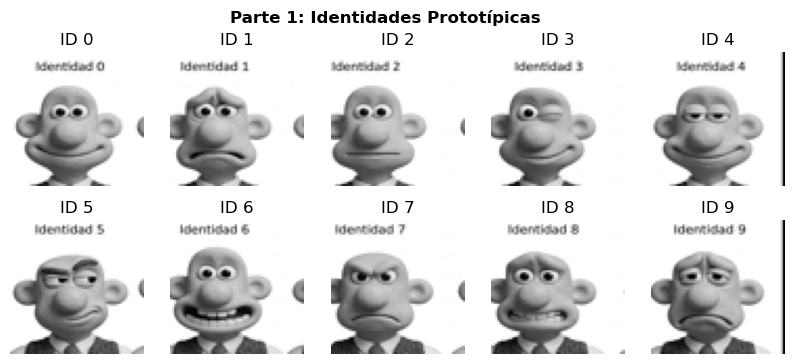

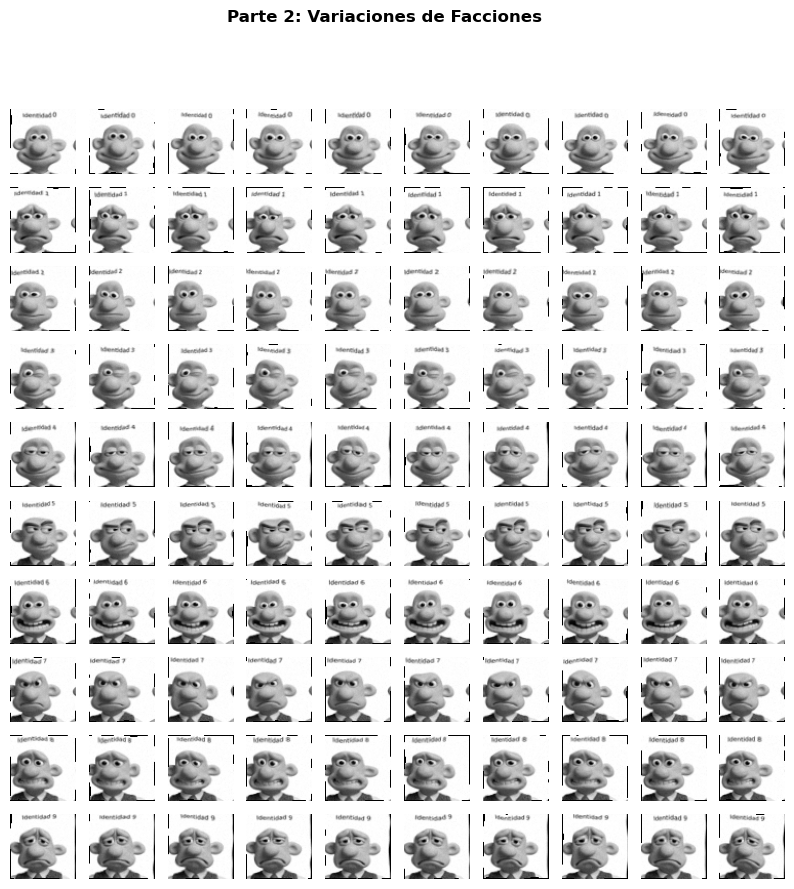

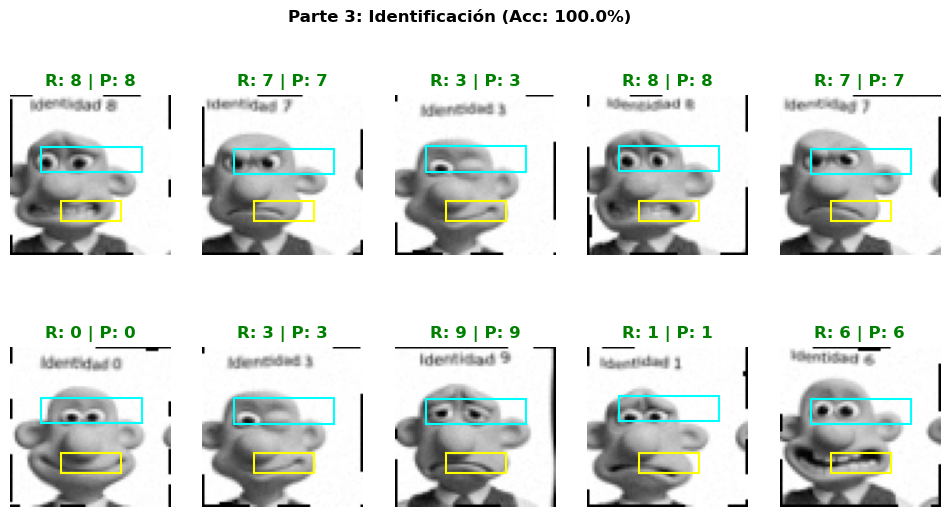

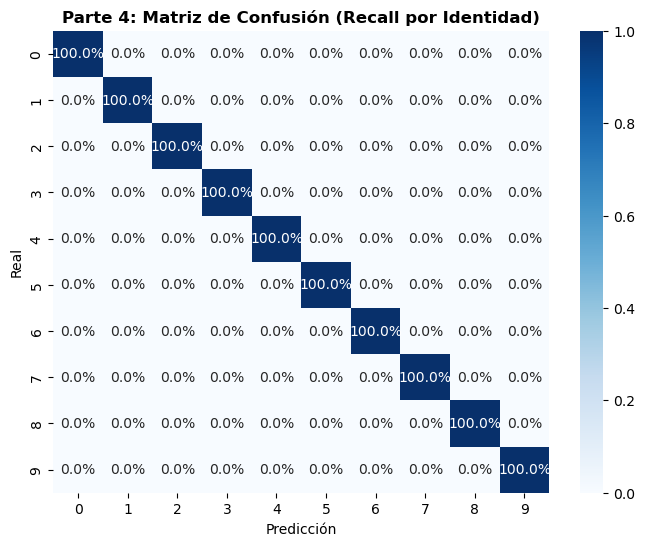

In [10]:
"""
================================================================================
RETO RIDGE REGRESSION - DREAMTEAM 
Versión Final: Prototipos + Variantes + Extracción + Matriz (Implementación Manual)
================================================================================
"""
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from scipy.ndimage import gaussian_filter, map_coordinates
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

# --- CONFIGURACIÓN ---
RNG = np.random.default_rng(42)
IMG_SIZE = 64          
N_IDENTIDADES = 10     
N_COLUMNAS = 5         
N_POR_IDENTIDAD = 100  

# Parámetros geométricos para la Parte 3
PARAM_BASE = np.array([
    [0.2, 0.5, -0.2, 0.4], [0.3, 0.6, -0.3, 0.3], [0.2, 0.5, -0.2, 0.2], 
    [0.2, 0.1, -0.2, 0.5], [0.2, 0.3, -0.2, 0.4], [0.4, 0.5, -0.1, 0.4], 
    [0.2, 0.6, -0.3, 0.6], [0.1, 0.4, -0.2, 0.5], [0.2, 0.5, -0.3, 0.5], 
    [0.2, 0.4, -0.4, 0.3]
])

def ridge_manual(X, y, alpha):
    """
    Implementación manual de Ridge Regression usando la ecuación normal.
    Requisito obligatorio según rúbrica (Acción 13).
    """
    n_features = X.shape[1]
    I = np.eye(n_features)
    # Resolución de (X'X + alpha*I) * beta = X'y
    beta = np.linalg.solve(X.T @ X + alpha * I, X.T @ y)
    return beta

def elastic_transform(image, alpha, sigma):
    """Aplica deformación elástica para aumento de datos."""
    shape = image.shape
    dx = gaussian_filter((RNG.random(shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    dy = gaussian_filter((RNG.random(shape) * 2 - 1), sigma, mode="constant", cval=0) * alpha
    x, y = np.meshgrid(np.arange(shape[0]), np.arange(shape[1]), indexing='ij')
    indices = np.reshape(x+dx, (-1, 1)), np.reshape(y+dy, (-1, 1))
    return map_coordinates(image, indices, order=1).reshape(shape)

def cargar_y_cortar(ruta_img):
    """Carga la imagen, recorta las 10 identidades y normaliza."""
    try:
        full_img = Image.open(ruta_img).convert('L')
        ancho_c, alto_c = full_img.size[0] // N_COLUMNAS, full_img.size[1] // 2
        prototipos = []
        for i in range(N_IDENTIDADES):
            fila, col = i // N_COLUMNAS, i % N_COLUMNAS
            izq, top = (col * ancho_c) + int(ancho_c * 0.03), fila * alto_c
            celda = full_img.crop((izq, top, izq + ancho_c, top + alto_c))
            cara = celda.crop((0, int(celda.size[1]*0.15), celda.size[0], celda.size[1]))
            prototipos.append(np.array(cara.resize((IMG_SIZE, IMG_SIZE))) / 255.0)
        return prototipos
    except: return None

# --- PROCESAMIENTO ---
X_base = cargar_y_cortar('expresiones.png') # Cambiar a tu nombre de archivo

if X_base is not None:
    X, y, P = [], [], []
    muestreo_p2 = []

    for ident in range(N_IDENTIDADES):
        temp_v = []
        for j in range(N_POR_IDENTIDAD):
            img_v = elastic_transform(X_base[ident], alpha=IMG_SIZE*0.3, sigma=IMG_SIZE*0.08)
            img_v = np.clip(img_v + RNG.normal(0, 0.01, img_v.shape), 0, 1)
            X.append(img_v.ravel()); y.append(ident); P.append(PARAM_BASE[ident])
            if j < 10: temp_v.append(img_v)
        muestreo_p2.append(temp_v)
        
    X, y, P = np.array(X), np.array(y), np.array(P)
    
    # Estandarización (Media y Std solo del entrenamiento - Acción 16)
    X_train, X_test, y_train, y_test, P_train, P_test = train_test_split(X, y, P, test_size=0.3, stratify=y)
    mu, sigma = X_train.mean(axis=0), X_train.std(axis=0) + 1e-7
    X_train_s = (X_train - mu) / sigma
    X_test_s = (X_test - mu) / sigma

    # Entrenamiento Manual (Ridge Multivariado)
    y_train_oh = np.eye(N_IDENTIDADES)[y_train]
    beta_clf = ridge_manual(X_train_s, y_train_oh, alpha=1.0)
    beta_param = ridge_manual(X_train_s, P_train, alpha=1.0)

    # Predicciones
    y_pred = np.argmax(X_test_s @ beta_clf, axis=1)
    p_pred = X_test_s @ beta_param
    acc = accuracy_score(y_test, y_pred)

    # PARTE 1: Prototipos
    fig1, ax1 = plt.subplots(2, 5, figsize=(10, 4))
    for i, ax in enumerate(ax1.flat):
        ax.imshow(X_base[i], cmap='gray'); ax.axis('off'); ax.set_title(f"ID {i}")
    plt.suptitle("Parte 1: Identidades Prototípicas", fontweight='bold'); plt.show()

    # PARTE 2: Variantes
    fig2, ax2 = plt.subplots(10, 10, figsize=(10, 10))
    for i in range(10):
        for j in range(10):
            ax2[i,j].imshow(muestreo_p2[i][j], cmap='gray'); ax2[i,j].axis('off')
    plt.suptitle("Parte 2: Variaciones de Facciones", fontweight='bold'); plt.show()

    # PARTE 3: Identificación + Extracción
    fig3, ax3 = plt.subplots(2, 5, figsize=(12, 6))
    for i, ax in enumerate(ax3.flat):
        idx = RNG.integers(0, len(X_test))
        ax.imshow(X_test[idx].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        h_ojos = 20 - (p_pred[idx, 0] * 10)
        ax.add_patch(plt.Rectangle((12, h_ojos), 40, 10, fill=False, edgecolor='cyan', lw=1.5))
        ax.add_patch(plt.Rectangle((20, 42), 24, 8, fill=False, edgecolor='yellow', lw=1.5))
        color = 'green' if y_test[idx] == y_pred[idx] else 'red'
        ax.set_title(f"R: {y_test[idx]} | P: {y_pred[idx]}", color=color, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f"Parte 3: Identificación (Acc: {acc*100:.1f}%)", fontweight='bold'); plt.show()

    # PARTE 4: Matriz de Confusión en Porcentajes (Requisito Acción 19)
    cm = confusion_matrix(y_test, y_pred)
    cm_perc = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_perc, annot=True, fmt='.1%', cmap='Blues')
    plt.title(f"Parte 4: Matriz de Confusión (Recall por Identidad)", fontweight='bold')
    plt.xlabel("Predicción"); plt.ylabel("Real"); plt.show()